# 311 Requests and Metro Bus Proximity (LA)

**Goal**: Analyze whether proximity to metro bus infrastructure correlates with the volume or type of 311 requests in Los Angeles. Compare with metro rail analysis to test urban proximity vs. metro-specific effects. Utilize results to strengthen causal framing.

This notebook:
- Loads and cleans 311 request data
- Joins with Neighborhood Council and population data
- Computes distance to nearest metro bus stop
- Visualizes request patterns spatially



# Section 1: Setup

In [1]:
# Install necessary packages and run only once per environment

# !pip install geopandas shapely folium pyproj datasets matplotlib seaborn pandas requests

In [2]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from shapely.geometry import Point
from shapely.ops import nearest_points

from notebooks.metro_311_project_setup import metro_union, nc_population

/opt/anaconda3/envs/ds-modern/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from pathlib import Path

nb_dir = Path().resolve()

project_root = nb_dir.parent

DATA_RAW = project_root / "data" / "raw"
DATA_CLEANED = project_root / "data" / "cleaned"

# Section 2: Load 311 Data (2024)

In [4]:
dataset = load_dataset("311-data/2024", split="train")
df_311 = dataset.to_pandas()
df_311.shape

(1442297, 34)

# Section 3: Load Metro Bus Data

In [5]:
# Data downloaded from https://developer.metro.net/gis-data/

# Stops Serving Lines
# This shapefile contains a separate point for each stop. For example, stop 1 at Paramount / Slauson is represented by a single point.  The data attribute table has columns that show this stop is served by lines 108 and 265.

bus_stops = gpd.read_file(DATA_CLEANED / 'StopServingStops0625/StopServingStops0625.shp')

# Section 4: Load Neighbourhood Councils and Population Data

In [6]:
# The extraction from raw data is performed in the previous step with the metro rail analysis and the cleaned file is being used here directly.

df = pd.read_csv(DATA_CLEANED / 'nc_demographics_2020.csv')

In [7]:
# Latest NC boundaries: https://geohub.lacity.org/datasets/lahub::neighborhood-council-boundaries-2018/about
# Last updated on Jan 19, 2023
# 99 records

nc_geo = gpd.read_file(DATA_CLEANED / 'Neighborhood_Council_Boundaries_(2018)/Neighborhood_Council_Boundaries_(2018).shp')

In [8]:
nc_geo["NC_Name"] = nc_geo["Name"]
nc_geo_merged = nc_geo.merge(df, on="NC_Name", how="left")

# Section 5: Population Density Calculation

In [11]:
# WGS84 (EPSG:4326) uses degrees, not meters, bad for area. Reproject to something like:
# UTM Zone 11N → EPSG:32611 (simple, good accuracy for SoCal)
# Or California Albers → EPSG:3310 (statewide analyses)
# Or State Plane CA Zone 5 (meters) → EPSG:26945 (very precise for LA County)
# We go with 26945

nc_proj = nc_geo_merged.to_crs(epsg=26945)

In [12]:
# First getting the area which will be in square meters
nc_proj["Area_m2"] = nc_proj.geometry.area

# Then converting to square miles (1 square mile = 2,589,988.11 square miles)
nc_proj["Area_mi2"] = nc_proj["Area_m2"] / 2_589_988.11

# Calculating population density per square mile
nc_proj["Pop_Density_per_mi2"] = nc_proj["Population"] / nc_proj["Area_mi2"]

# Section 6: Spatial Join Between 311 Requests and NC Data

In [13]:
# Dropping rows without any coordinates
df_311_2024 = df_311.dropna(subset=["Latitude", "Longitude"])

# First creating Point geometries from lat/long columns, so we can use GeoPandas before reprojecting to 3857 same as nc_proj
geometry = [Point(xy) for xy in zip(df_311_2024["Longitude"], df_311_2024["Latitude"])]
gdf_311 = gpd.GeoDataFrame(df_311_2024, geometry=geometry, crs="EPSG:4326")

gdf_311_proj = gdf_311.to_crs(nc_proj.crs)

# Keeping 311 requests that fall within a neighbourhood council boundary and dropping the rest
gdf_311_joined = gpd.sjoin(gdf_311_proj, nc_proj, how="inner", predicate="within")

# Assigned name for the project going forward as standardized by the NC website to avoid confusion
gdf_311_joined["NC_Assigned"] = gdf_311_joined["NC_Name"]

In [16]:
gdf_311_proj = gdf_311_joined.to_crs(nc_proj.crs)
bus_proj = bus_stops.to_crs(nc_proj.crs)

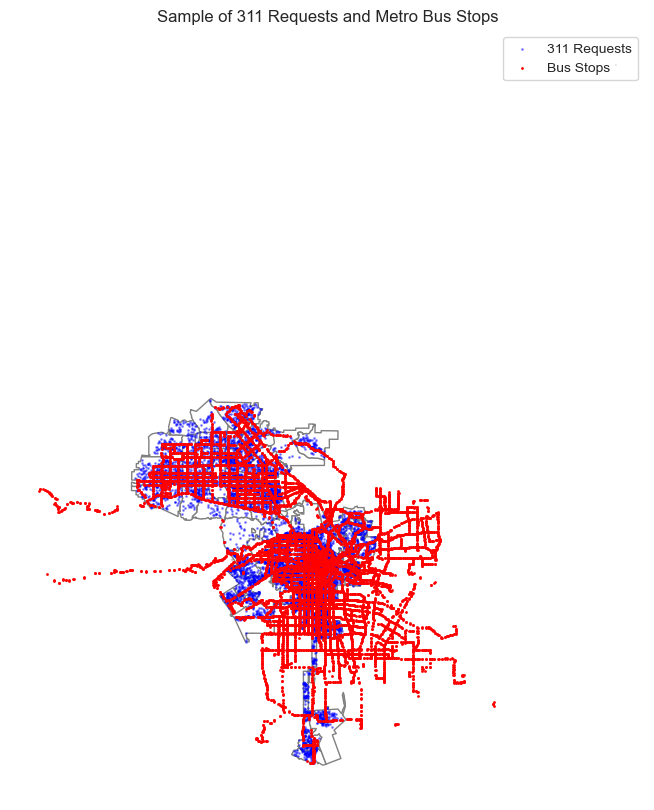

In [19]:
# Plot: Sampled 311 requests in the neighbourhood council boundary with bus stops

sample_311 = gdf_311_proj.sample(10000, random_state=42)

ax = nc_proj.plot(color="white", edgecolor="gray", figsize=(12, 10))
sample_311.plot(ax=ax, markersize=1, color="blue", alpha=0.4, label="311 Requests")
bus_proj.plot(ax=ax, color="red", markersize=1, label="Bus Stops")
plt.title("Sample of 311 Requests and Metro Bus Stops")
plt.legend()
plt.axis("off")
plt.show()

Visually, the metro bus stops have more coverage of the city compared to the metro rail stops and the density of requests does seem to be higher around the bus stops, will need further inspection to ascertain.

# Section 7: Join 311 Requests To Metro Bus Stops

In [20]:
# Creating a unary union to make individual geometries to a single one to make the lookup in the join faster.
bus_union = bus_proj.union_all()

# Using distance instead of nearest_points
gdf_311_proj["DistToBusStop_m"] = gdf_311_proj.geometry.distance(bus_union)

# Converting distance from meters to feet
gdf_311_proj["DistToBusStop_ft"] = gdf_311_proj["DistToBusStop_m"] * 3.28084

# Flagging requests within walkable buffer zones
gdf_311_proj["Within_500ft"] = gdf_311_proj["DistToBusStop_ft"] <= 500
gdf_311_proj["Within_1000ft"] = gdf_311_proj["DistToBusStop_ft"] <= 1000
gdf_311_proj["Within_1320ft"] = gdf_311_proj["DistToBusStop_ft"] <= 1320 # 0.25 miles
gdf_311_proj["Within_2640ft"] = gdf_311_proj["DistToBusStop_ft"] <= 2640 # 0.5 miles

print("Share of requests within 500 ft of a bus stop:")
print(f"{gdf_311_proj["Within_500ft"].mean():.2%}")

print("\nShare of requests within 1000 ft of a bus stop:")
print(f"{gdf_311_proj["Within_1000ft"].mean():.2%}")

print("\nShare of requests within 1320 ft / 0.25 miles of a bus stop:")
print(f"{gdf_311_proj["Within_1320ft"].mean():.2%}")

print("\nShare of requests within 2640 ft / 0.5 miles of a bus stop:")
print(f"{gdf_311_proj["Within_2640ft"].mean():.2%}")


Share of requests within 500 ft of a bus stop:
40.50%

Share of requests within 1000 ft of a bus stop:
72.44%

Share of requests within 1320 ft / 0.25 miles of a bus stop:
82.00%

Share of requests within 2640 ft / 0.5 miles of a bus stop:
93.61%


Text(0.5, 0, 'In Feet')

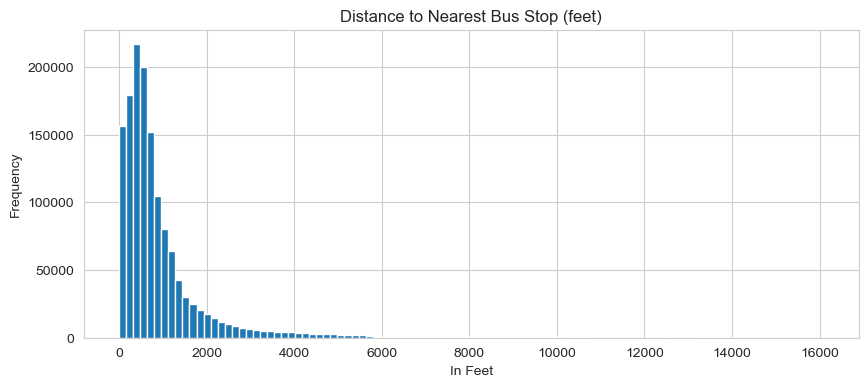

In [21]:
# Plot: Distance to nearest bus stop - histogram

gdf_311_proj["DistToBusStop_ft"].plot.hist(bins=100, figsize=(10,4))
plt.title("Distance to Nearest Bus Stop (feet)")
plt.xlabel("In Feet")

# Section 8: 311 Request Rates by Bus Proximity

### Step 1: Define distance bands

In [22]:
gdf_311_proj["BusProximity"] = pd.cut(
    gdf_311_proj["DistToBusStop_ft"],
    bins=[0, 500, 1320, 2640, float("inf")],
    labels=["<500ft", "500-1320ft", "1320-2640ft", ">2640ft"]
)

In [23]:
gdf_311_proj["BusProximity"].value_counts()

BusProximity
500-1320ft     588637
<500ft         574365
1320-2640ft    164748
>2640ft         90607
Name: count, dtype: int64

### Step 2: Normalize request rates per capita

In [24]:
request_counts = (
    gdf_311_proj
    .groupby(["NC_Assigned", "BusProximity"], observed=False)
    .size()
    .reset_index(name="Request_Count")
)

In [25]:
nc_population = nc_proj[["NC_Name", "Population"]]

merged = request_counts.merge(nc_population, left_on="NC_Assigned", right_on="NC_Name", how="left")

merged["Rate_per_1000"] = (merged["Request_Count"] / merged["Population"]) * 1000

merged

,NC_Assigned,BusProximity,Request_Count,NC_Name,Population,Rate_per_1000
0,Arleta,<500ft,3940,Arleta,36823,106.998343
1,Arleta,500-1320ft,6173,Arleta,36823,167.639790
2,Arleta,1320-2640ft,2221,Arleta,36823,60.315564
3,Arleta,>2640ft,0,Arleta,36823,0.000000
4,Arroyo Seco,<500ft,2098,Arroyo Seco,19861,105.634157
...,...,...,...,...,...,...
391,Woodland Hills-Warner Center,>2640ft,2029,Woodland Hills-Warner Center,76422,26.549946
392,Zapata King,<500ft,7694,Zapata King,54784,140.442465
393,Zapata King,500-1320ft,7614,Zapata King,54784,138.982185
394,Zapata King,1320-2640ft,32,Zapata King,54784,0.584112


### Step 3: Plot request rate by proximity band

In [26]:
rate_by_band = (
    merged.groupby("BusProximity")["Rate_per_1000"]
    .mean()
    .reset_index()
)

/var/folders/j2/flpzfpnd6vb9fc48rxpk30900000gn/T/ipykernel_46982/2279086006.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged.groupby("BusProximity")["Rate_per_1000"]


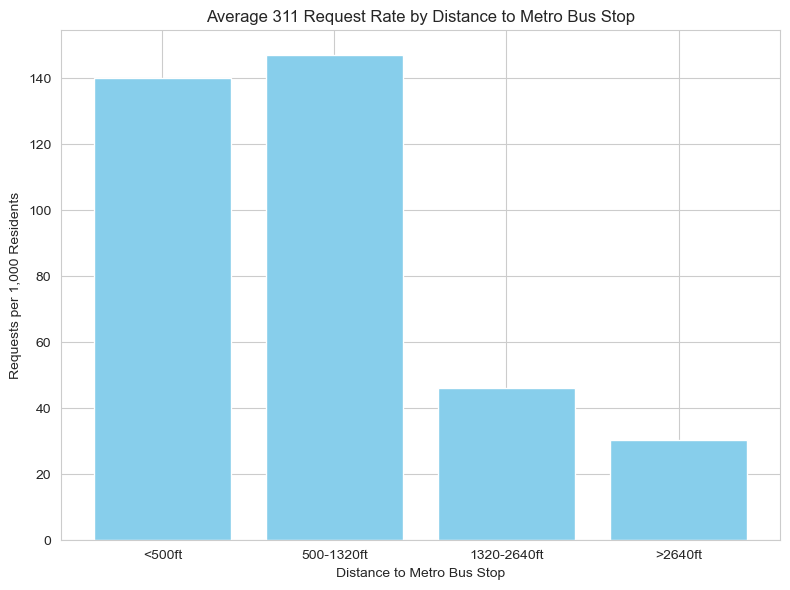

In [27]:
plt.figure(figsize=(8, 6))
plt.bar(rate_by_band["BusProximity"], rate_by_band["Rate_per_1000"], color="skyblue")
plt.title("Average 311 Request Rate by Distance to Metro Bus Stop")
plt.xlabel("Distance to Metro Bus Stop")
plt.ylabel("Requests per 1,000 Residents")
plt.tight_layout()
plt.show()

### Step 5: Per capita requests by NC x request type x bus stop proximity

In [28]:
grouped = (
    gdf_311_proj
    .groupby(["NC_Assigned", "BusProximity", "RequestType"])
    .size()
    .reset_index(name="Request_Count")
)

grouped = grouped.merge(
    nc_proj[["NC_Name", "Population"]],
    left_on="NC_Assigned", right_on="NC_Name",
    how="left"
)

grouped[grouped["Population"].isna()]

/var/folders/j2/flpzfpnd6vb9fc48rxpk30900000gn/T/ipykernel_46982/1200398909.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["NC_Assigned", "BusProximity", "RequestType"])


,NC_Assigned,BusProximity,RequestType,Request_Count,NC_Name,Population


In [29]:
grouped["Rate_per_1000"] = (grouped["Request_Count"] / grouped["Population"]) * 1000

/var/folders/j2/flpzfpnd6vb9fc48rxpk30900000gn/T/ipykernel_46982/654051273.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped.groupby(["RequestType", "BusProximity"])["Request_Count"]


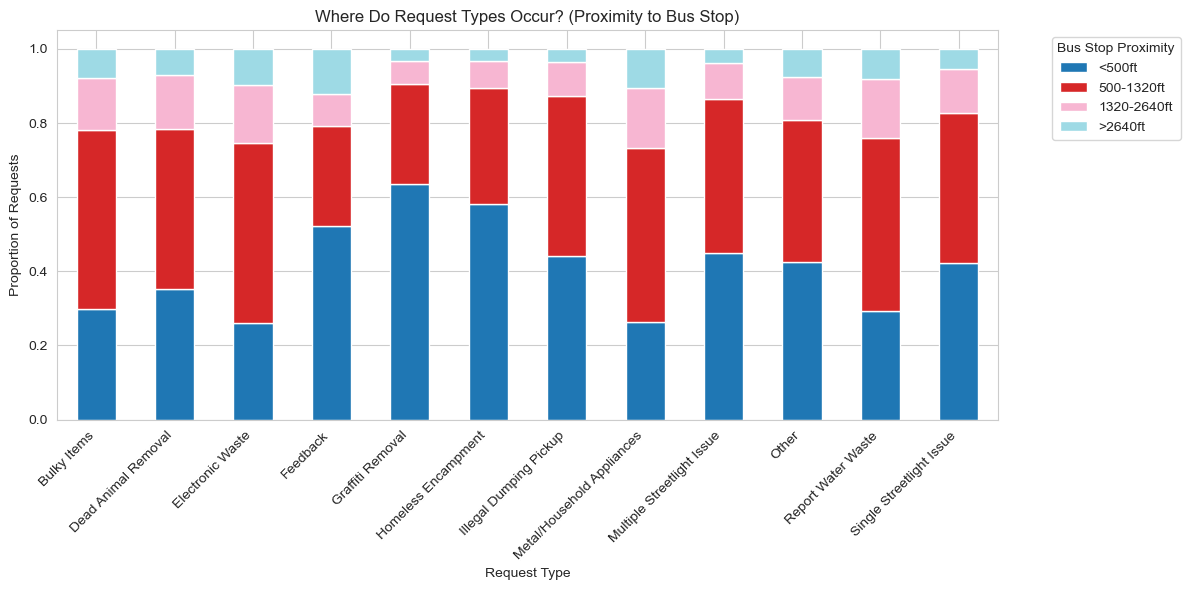

In [30]:
# Summarize request counts across all NCs
type_by_prox = (
    grouped.groupby(["RequestType", "BusProximity"])["Request_Count"]
    .sum()
    .reset_index()
)

# Pivot: rows = Request Type, columns = Bus Proximity
pivot_df = type_by_prox.pivot(
    index="RequestType",
    columns="BusProximity",
    values="Request_Count"
).fillna(0)

# Normalize rows to get proportions
proportion_df = pivot_df.div(pivot_df.sum(axis=1), axis=0)

# Plot: Request types by proximity to metro bus stop
proportion_df.plot(
    kind="bar", stacked=True, figsize=(12, 6), colormap="tab20"
)
plt.title("Where Do Request Types Occur? (Proximity to Bus Stop)")
plt.xlabel("Request Type")
plt.ylabel("Proportion of Requests")
plt.legend(title="Bus Stop Proximity", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


/var/folders/j2/flpzfpnd6vb9fc48rxpk30900000gn/T/ipykernel_46982/4238527201.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped.groupby(["BusProximity", "RequestType"])["Request_Count"]


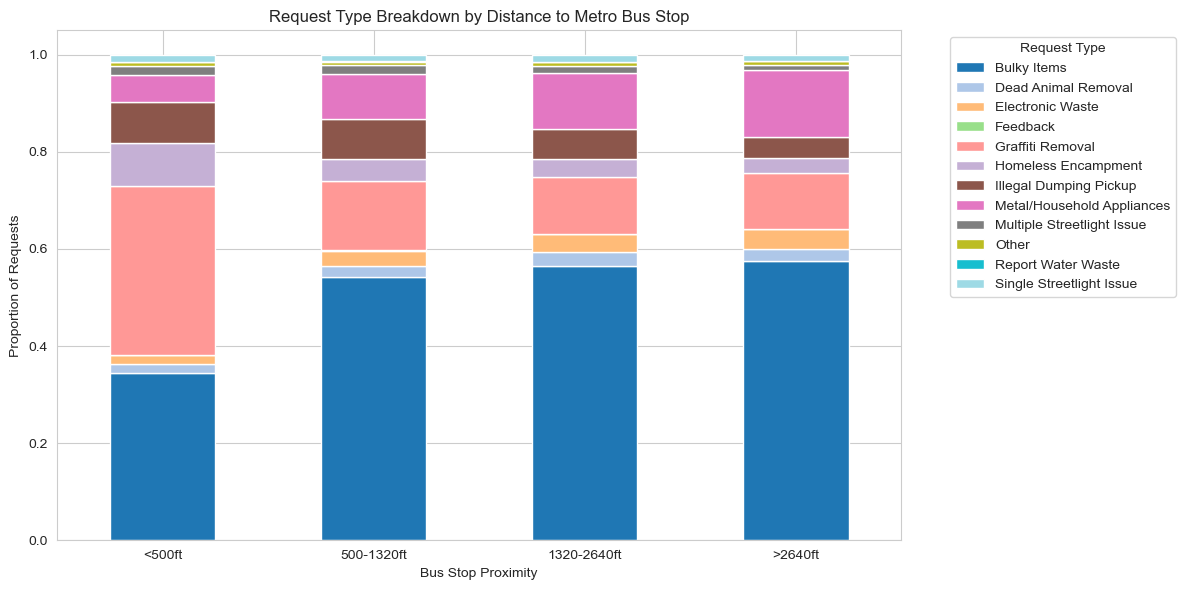

In [31]:
# Group again: total count by Bus Proximity and Request Type
prox_by_type = (
    grouped.groupby(["BusProximity", "RequestType"])["Request_Count"]
    .sum()
    .reset_index()
)

# Pivot: rows = Bus Proximity, columns = Request Type
pivot_df_flipped = prox_by_type.pivot(
    index="BusProximity",
    columns="RequestType",
    values="Request_Count"
).fillna(0)

# Normalize rows to get proportions
proportion_df_flipped = pivot_df_flipped.div(pivot_df_flipped.sum(axis=1), axis=0)

# Plot
proportion_df_flipped.plot(
    kind="bar", stacked=True, figsize=(12, 6), colormap="tab20"
)
plt.title("Request Type Breakdown by Distance to Metro Bus Stop")
plt.xlabel("Bus Stop Proximity")
plt.ylabel("Proportion of Requests")
plt.legend(title="Request Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


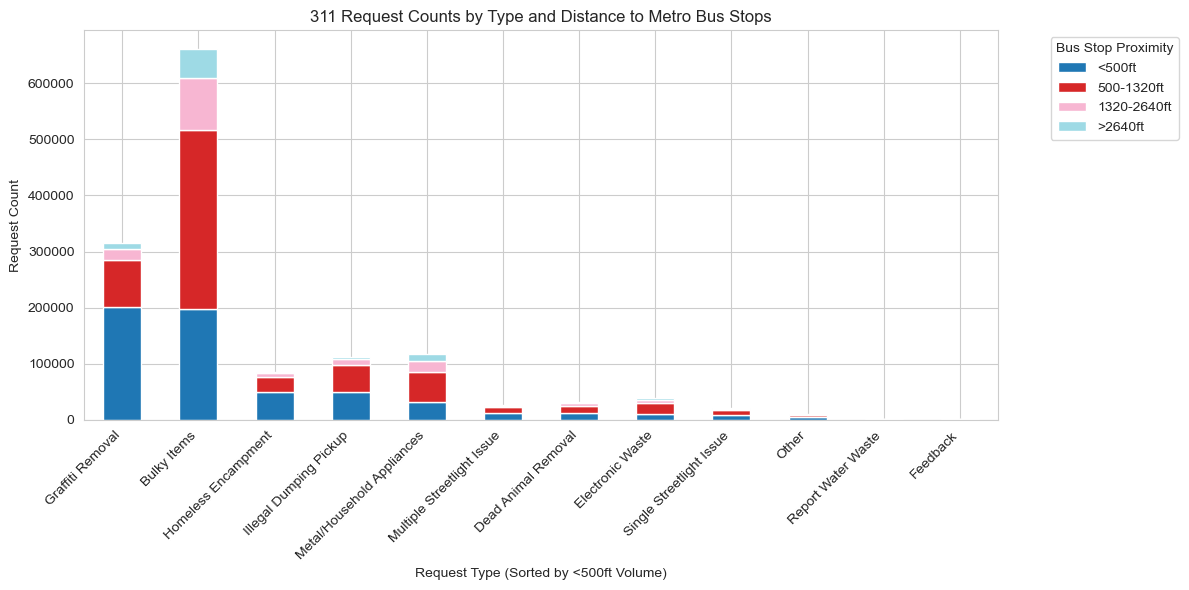

In [32]:
# Sort by <500ft count
sorted_df = pivot_df.sort_values(by="<500ft", ascending=False)

# Plot absolute stacked counts (not proportions)
sorted_df.plot(
    kind="bar", stacked=True, figsize=(12, 6), colormap="tab20"
)
plt.title("311 Request Counts by Type and Distance to Metro Bus Stops")
plt.xlabel("Request Type (Sorted by <500ft Volume)")
plt.ylabel("Request Count")
plt.legend(title="Bus Stop Proximity", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

/var/folders/j2/flpzfpnd6vb9fc48rxpk30900000gn/T/ipykernel_46982/2656728307.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["RequestType", "BusProximity"])["Rate_per_1000"]


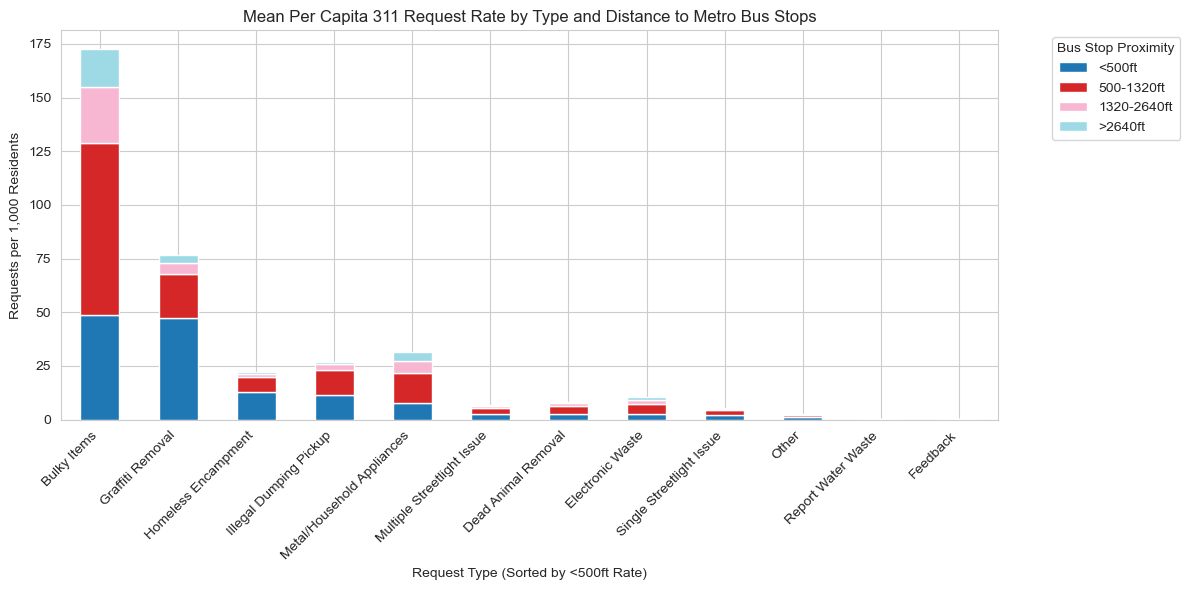

In [33]:
# Average per capita rate across NCs (no population sum)
avg_per_capita = (
    grouped
    .groupby(["RequestType", "BusProximity"])["Rate_per_1000"]
    .mean()
    .reset_index()
)

# Pivot and sort
pivot_rate = avg_per_capita.pivot(
    index="RequestType",
    columns="BusProximity",
    values="Rate_per_1000"
).fillna(0)

pivot_rate_sorted = pivot_rate.sort_values(by="<500ft", ascending=False)

# Plot
pivot_rate_sorted.plot(
    kind="bar", stacked=True, figsize=(12, 6), colormap="tab20"
)
plt.title("Mean Per Capita 311 Request Rate by Type and Distance to Metro Bus Stops")
plt.xlabel("Request Type (Sorted by <500ft Rate)")
plt.ylabel("Requests per 1,000 Residents")
plt.legend(title="Bus Stop Proximity", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## Summary: Bus Stop Proximity & 311 Requests (Control Case)

### Key Question:

Do bus stops show similar patterns of 311 service requests as metro rail stops, or are rail-specific effects visible after adjusting for population?

### This Notebook Covers:

- Computed distance bands from bus stops (`<500ft`, `500–1320ft`, `1320–2640ft`, `>2640ft`)
- Joined NC-level population data to normalize request counts
- Calculated per capita 311 request rates (per 1,000 residents) by proximity band
- Visualized:
    - Absolute and per capita request volumes by bus stop proximity
    - Distribution of request types across bands
    - Request clustering relative to bus stop density

### Key Insights So Far:

- The **vast majority of requests** occur near bus stops: \~40% within 500ft, \~72% within 1000ft, and \~94% within half a mile
- Per capita rates are elevated within 0.25 miles of bus stops, consistent with dense coverage across the city
- Request types like graffiti and bulky items are concentrated near bus stops, but this may reflect **general urban density** rather than bus-specific effects

### Next Steps:

- Compare metro and bus results directly, side by side
  - Per capita normalization
  - Request type distributions
  - Proximity-based charts
- Use regression or matching to test whether metro stops exhibit **unique effects** beyond what bus stop coverage explains
- Extend analysis to multiple years (2020–2024) for temporal robustness

### Notes:

* This notebook serves as the **control case** for the metro analysis
* Together with the rail notebook, it sets up the foundation for a combined causal framing around transit infrastructure and 311 requests
